In [32]:
# !pip install pyarrow matplotlib pandas numpy

# Workflow Performance Profiling

Loads a Flowcept parquet file and produces a full performance characterization:
timing, CPU, GPU, IO, memory, and compute-node distribution — all from the parquet alone.

In [33]:
# ── Config ────────────────────────────────────────────────────────────────────
WORKFLOW_ID = "1f11b21a-f5e5-4b01-bcd1-b3e00a71d4c5"
PARQUET_PATH = f"flowcept_output/tasks/tasks_{WORKFLOW_ID}.parquet"

In [34]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime, timezone

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8fafc',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

PALETTE = ['#0ea5e9','#22c55e','#f97316','#a855f7','#ef4444','#eab308','#14b8a6','#f43f5e']

raw = pd.read_parquet(PARQUET_PATH)
print(f"Loaded {len(raw)} tasks  |  columns: {list(raw.columns)}")

Loaded 128 tasks  |  columns: ['activity_id', 'workflow_id', 'campaign_id', 'used', 'started_at', 'hostname', 'task_id', 'telemetry_at_start', 'status', 'ended_at', 'telemetry_at_end', 'generated', 'finished']


In [35]:
# ── Feature extraction ────────────────────────────────────────────────────────
def _get(d, *keys, default=None):
    for k in keys:
        if not isinstance(d, dict):
            return default
        d = d.get(k, default)
        if d is None:
            return default
    return d

def _arr(v):
    """Scalar from ndarray/scalar."""
    if hasattr(v, '__len__'):
        return float(np.max(v)) if len(v) else None
    try:
        return float(v)
    except (TypeError, ValueError):
        return None

def extract(row):
    s = row['telemetry_at_start'] or {}
    e = row['telemetry_at_end']   or {}

    def delta(path):
        a, b = _arr(_get(s, *path)), _arr(_get(e, *path))
        return (b - a) if a is not None and b is not None else None

    def end_val(path):
        return _arr(_get(e, *path))

    # process IO (reads /proc/<pid>/io — captures VFS / Lustre IO)
    io_r = delta(['process','io_counters','read_bytes'])
    io_w = delta(['process','io_counters','write_bytes'])

    # GPU: first visible GPU
    gpu_s = _get(s, 'gpu') or {}
    gpu_e = _get(e, 'gpu') or {}
    gpu_key = next(iter(gpu_e), None)
    gpu_used_end  = _arr(_get(gpu_e, gpu_key, 'used'))  if gpu_key else None
    gpu_used_start= _arr(_get(gpu_s, gpu_key, 'used'))  if gpu_key else None
    gpu_delta = (gpu_used_end - gpu_used_start) if (gpu_used_end and gpu_used_start) else None

    # GPU temperature: max of all temp values at end
    gpu_temp = None
    if gpu_key:
        temp_dict = _get(gpu_e, gpu_key, 'temperature') or {}
        temps = [_arr(v) for v in temp_dict.values() if _arr(v) is not None]
        gpu_temp = max(temps) if temps else None

    elapsed = (row['ended_at'] - row['started_at']) if row['ended_at'] and row['started_at'] else None

    return dict(
        activity        = row['activity_id'],
        status          = row['status'],
        hostname        = row.get('hostname', 'unknown'),
        started_at      = row['started_at'],
        ended_at        = row['ended_at'],
        elapsed_s       = elapsed,
        cpu_user_s      = delta(['process','cpu_times','user']),
        cpu_sys_s       = delta(['process','cpu_times','system']),
        sys_cpu_pct     = end_val(['cpu','percent_all']),
        mem_rss_mb      = max(filter(None, [_arr(_get(s,'process','memory','rss')),
                                             _arr(_get(e,'process','memory','rss'))] or [None])) / 1e6
                          if any(_arr(_get(x,'process','memory','rss')) for x in (s,e)) else None,
        mem_virt_pct    = end_val(['memory','virtual','percent']),
        io_read_mb      = (io_r / 1e6) if io_r is not None else None,
        io_write_mb     = (io_w / 1e6) if io_w is not None else None,
        io_total_mb     = ((io_r or 0) + (io_w or 0)) / 1e6 if (io_r is not None or io_w is not None) else None,
        net_recv_mb     = (delta(['network','netio_sum','bytes_recv']) or 0) / 1e6,
        net_sent_mb     = (delta(['network','netio_sum','bytes_sent']) or 0) / 1e6,
        gpu_used_mb     = (gpu_used_end / 1e6) if gpu_used_end else None,
        gpu_delta_mb    = (gpu_delta / 1e6) if gpu_delta else None,
        gpu_temp_c      = gpu_temp,
        proc_threads    = end_val(['process','num_threads']),
        ctx_voluntary   = delta(['process','num_ctx_switches','voluntary']),
    )

df = pd.DataFrame([extract(row) for _, row in raw.iterrows()])
t0 = df['started_at'].min()
df['t_start'] = df['started_at'] - t0
df['t_end']   = df['ended_at']   - t0

activities = df['activity'].unique().tolist()
act_color  = {a: PALETTE[i % len(PALETTE)] for i, a in enumerate(activities)}

df.head()

,activity,status,hostname,started_at,ended_at,elapsed_s,cpu_user_s,cpu_sys_s,sys_cpu_pct,mem_rss_mb,...,io_total_mb,net_recv_mb,net_sent_mb,gpu_used_mb,gpu_delta_mb,gpu_temp_c,proc_threads,ctx_voluntary,t_start,t_end
0,compute,FINISHED,frontier01258.frontier.olcf.ornl.gov,1.779423e+09,1.779423e+09,0.020047,0.01,0.02,6.1,275.935232,...,0.0,0.0,0.0,11.358208,NaN,51.0,11.0,0.0,0.000000,0.020047
1,compute,FINISHED,frontier01258.frontier.olcf.ornl.gov,1.779423e+09,1.779423e+09,0.019276,0.00,0.01,6.2,274.817024,...,0.0,0.0,0.0,11.358208,NaN,51.0,11.0,8.0,0.000376,0.019652
2,compute,FINISHED,frontier01258.frontier.olcf.ornl.gov,1.779423e+09,1.779423e+09,0.019422,0.01,0.01,6.2,274.817024,...,0.0,0.0,0.0,11.358208,NaN,51.0,11.0,12.0,0.000378,0.019800
3,compute,FINISHED,frontier01258.frontier.olcf.ornl.gov,1.779423e+09,1.779423e+09,0.019224,0.01,0.01,5.8,274.817024,...,0.0,0.0,0.0,11.358208,NaN,51.0,11.0,8.0,0.000389,0.019613
4,compute,FINISHED,frontier01258.frontier.olcf.ornl.gov,1.779423e+09,1.779423e+09,0.019725,0.01,0.01,6.0,274.817024,...,0.0,0.0,0.0,11.358208,NaN,51.0,11.0,8.0,0.000413,0.020138


## 1 · Workflow Overview

In [36]:
hostnames = df['hostname'].unique()
t_start_utc = datetime.fromtimestamp(t0, tz=timezone.utc).strftime('%Y-%m-%d %H:%M:%S UTC')
t_span = df['t_end'].max()

summary = pd.Series({
    'Workflow ID':        WORKFLOW_ID,
    'Start time':         t_start_utc,
    'Total elapsed (s)':  f"{t_span:.3f}",
    'Total tasks':        len(df),
    'Unique activities':  df['activity'].nunique(),
    'Compute nodes':      len(hostnames),
    'Node(s)':            ', '.join(sorted(hostnames)),
    'Status counts':      dict(df['status'].value_counts()),
}, name='value')
print(summary.to_string())

print()
print('Tasks per activity:')
print(df.groupby('activity').size().sort_values(ascending=False).to_string())

Workflow ID                       1f11b21a-f5e5-4b01-bcd1-b3e00a71d4c5
Start time                                     2026-05-22 04:08:17 UTC
Total elapsed (s)                                               14.887
Total tasks                                                        128
Unique activities                                                    4
Compute nodes                                                        2
Node(s)              frontier01258.frontier.olcf.ornl.gov, frontier...
Status counts                                        {'FINISHED': 128}

Tasks per activity:
activity
compute        80
cpu_compute    16
gpu_matmul     16
summarize      16


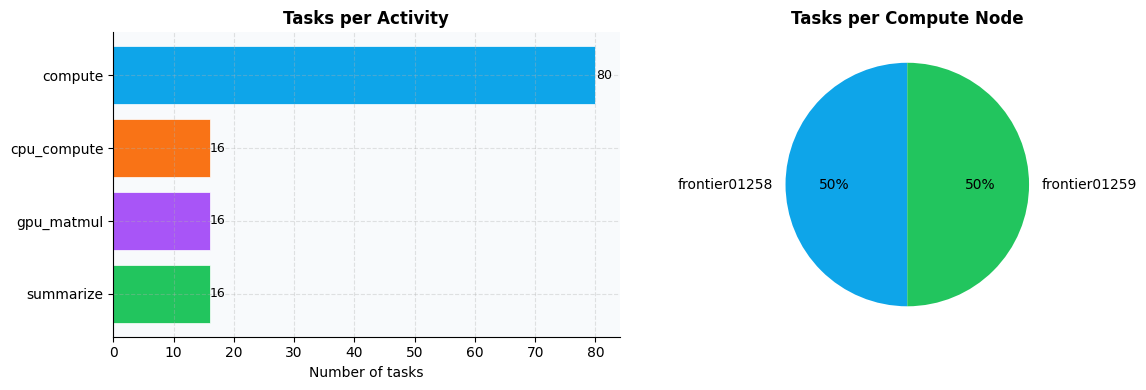

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Tasks per activity (bar)
counts = df.groupby('activity').size().sort_values(ascending=False)
colors = [act_color[a] for a in counts.index]
axes[0].barh(counts.index, counts.values, color=colors, edgecolor='white', linewidth=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(v + 0.05, i, str(v), va='center', fontsize=9)
axes[0].set_xlabel('Number of tasks')
axes[0].set_title('Tasks per Activity', fontweight='bold')
axes[0].invert_yaxis()

# Node distribution (pie or bar)
node_counts = df.groupby('hostname').size().sort_values(ascending=False)
short_names = [h.split('.')[0] for h in node_counts.index]  # strip domain
if len(node_counts) == 1:
    axes[1].bar(short_names, node_counts.values, color=PALETTE[0], edgecolor='white')
    axes[1].set_ylabel('Tasks')
else:
    axes[1].pie(node_counts.values, labels=short_names, autopct='%1.0f%%',
                colors=PALETTE[:len(node_counts)], startangle=90)
axes[1].set_title('Tasks per Compute Node', fontweight='bold')

fig.tight_layout()
plt.show()

## 2 · Execution Timeline (Gantt)

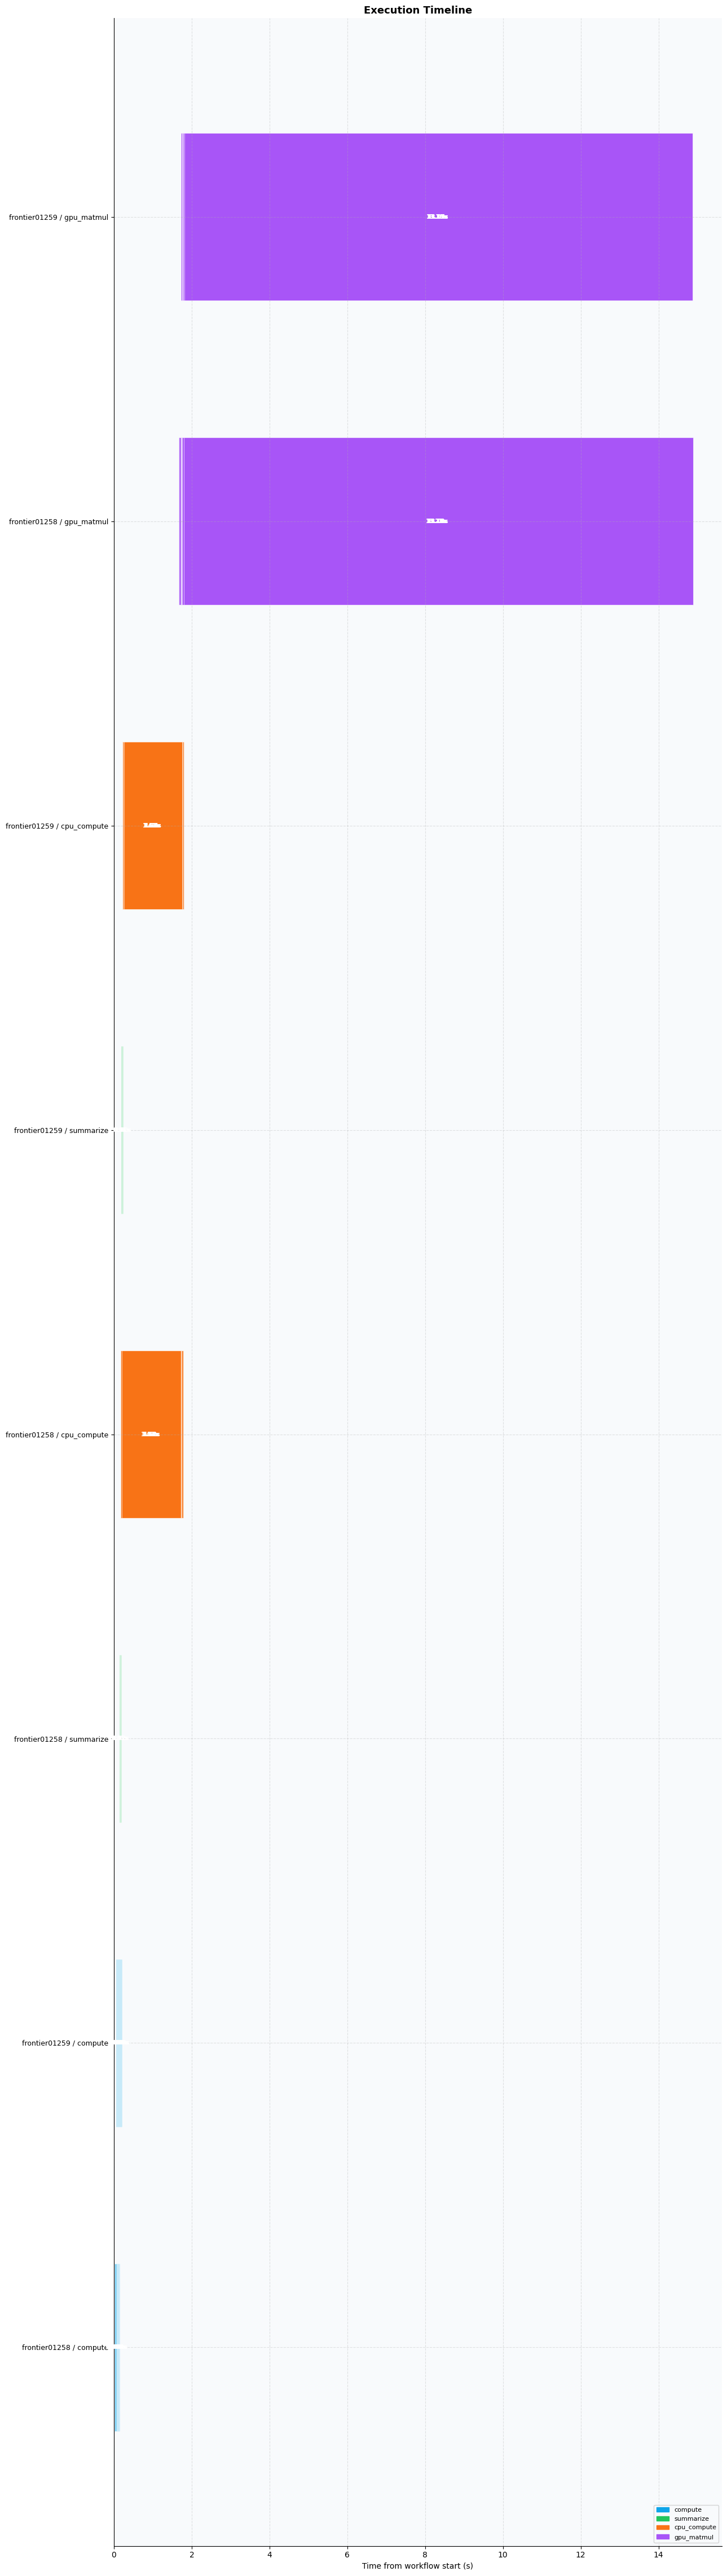

In [38]:
fig, ax = plt.subplots(figsize=(13, max(3, len(df) * 0.35 + 1)))

# One row per (hostname_short, activity) pair, or just activity if single node
multi_node = df['hostname'].nunique() > 1
if multi_node:
    df['_label'] = df['hostname'].str.split('.').str[0] + ' / ' + df['activity']
else:
    df['_label'] = df['activity']

labels_ordered = df.sort_values('t_start')['_label'].unique().tolist()
label_y = {lbl: i for i, lbl in enumerate(labels_ordered)}

for _, row in df.iterrows():
    y   = label_y[row['_label']]
    ax.barh(y, row['t_end'] - row['t_start'], left=row['t_start'],
            height=0.55, color=act_color[row['activity']],
            edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.text(row['t_start'] + (row['t_end'] - row['t_start']) / 2, y,
            f"{row['elapsed_s']:.2f}s", ha='center', va='center', fontsize=7, color='white', fontweight='bold')

ax.set_yticks(range(len(labels_ordered)))
ax.set_yticklabels(labels_ordered, fontsize=9)
ax.set_xlabel('Time from workflow start (s)')
ax.set_title('Execution Timeline', fontweight='bold', fontsize=13)

legend_patches = [mpatches.Patch(color=act_color[a], label=a) for a in activities]
ax.legend(handles=legend_patches, loc='lower right', fontsize=8, framealpha=0.8)
fig.tight_layout()
plt.show()

## 3 · Resource Usage Over Time

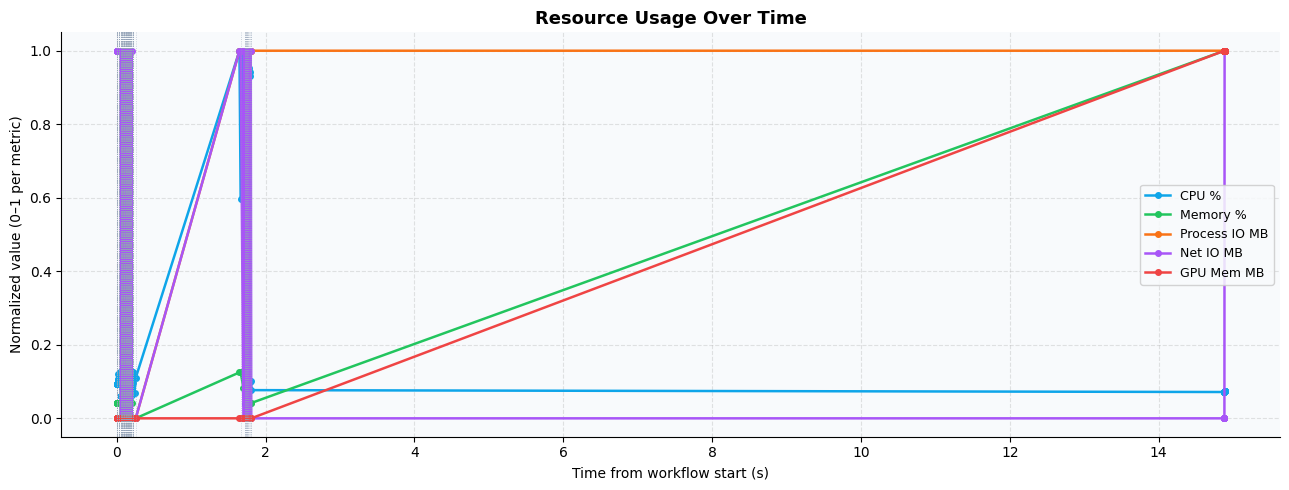

In [39]:
# Reconstruct time-series from start/end telemetry snapshots
def build_series(col_start_path, col_end_path=None):
    """Return (times, values) from per-task start/end snapshots, sorted by time."""
    pts = []
    for _, row in raw.iterrows():
        s = row['telemetry_at_start'] or {}
        e = row['telemetry_at_end']   or {}
        vs = _arr(_get(s, *col_start_path))
        ve = _arr(_get(e, *(col_end_path or col_start_path)))
        if vs is not None:
            pts.append((row['started_at'] - t0, vs))
        if ve is not None:
            pts.append((row['ended_at']   - t0, ve))
    pts.sort()
    if not pts:
        return [], []
    times, vals = zip(*pts)
    return list(times), list(vals)

metrics = [
    ('CPU %',        ['cpu','percent_all'],                        None,                '#0ea5e9'),
    ('Memory %',     ['memory','virtual','percent'],               None,                '#22c55e'),
    ('Process IO MB',['process','io_counters','write_bytes'],      None,                '#f97316'),
    ('Net IO MB',    ['network','netio_sum','bytes_recv'],         None,                '#a855f7'),
    ('GPU Mem MB',   ['gpu','gpu_0','used'],                       None,                '#ef4444'),
]

def normalize(vals):
    lo, hi = min(vals), max(vals)
    return [(v - lo) / (hi - lo) for v in vals] if hi > lo else None

# Scale IO and GPU to MB for readability
def scale(label, vals):
    if 'IO MB' in label or 'Mem MB' in label or 'Net IO MB' in label:
        return [v / 1e6 for v in vals]
    return vals

fig, ax = plt.subplots(figsize=(13, 5))

plotted = []
for label, start_path, end_path, color in metrics:
    times, vals = build_series(start_path, end_path)
    if len(vals) < 2:
        continue
    vals = scale(label, vals)
    normed = normalize(vals)
    if normed is None:
        continue
    ax.plot(times, normed, label=label, color=color, marker='o', linewidth=1.8, markersize=4)
    plotted.append(label)

# Vertical lines at each task start
for ts in df['t_start'].unique():
    ax.axvline(ts, color='#94a3b8', linewidth=0.6, linestyle=':', alpha=0.6)

ax.set_xlabel('Time from workflow start (s)')
ax.set_ylabel('Normalized value (0–1 per metric)')
ax.set_title('Resource Usage Over Time', fontweight='bold', fontsize=13)
ax.legend(fontsize=9, framealpha=0.85)
fig.tight_layout()
plt.show()

if not plotted:
    print('No telemetry data with sufficient variation found.')

## 4 · Per-Activity Elapsed Time

              Mean (s)  Median (s)    Min (s)    Max (s)   N
activity                                                    
gpu_matmul   13.134931   13.136626  13.074875  13.220051  16
cpu_compute   1.534345    1.529976   1.478827   1.619038  16
compute       0.015000    0.014478   0.011768   0.020047  80
summarize     0.013172    0.012538   0.012089   0.017553  16


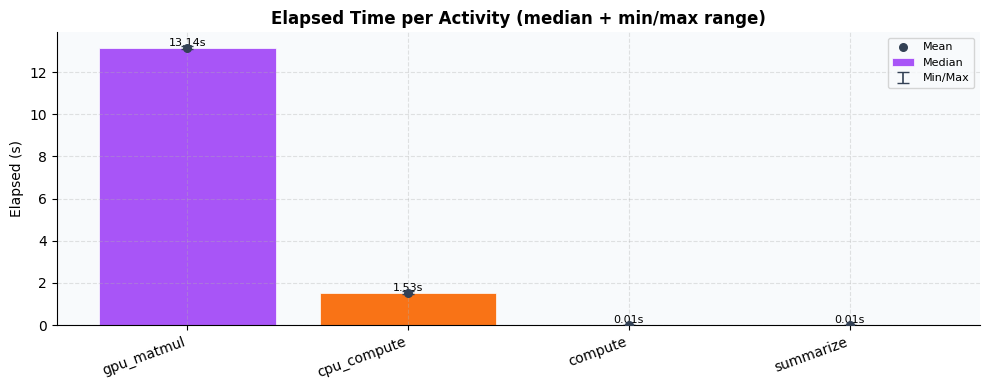

In [40]:
act_elapsed = df.groupby('activity')['elapsed_s'].agg(['mean','median','min','max','count'])
act_elapsed.columns = ['Mean (s)', 'Median (s)', 'Min (s)', 'Max (s)', 'N']
print(act_elapsed.sort_values('Median (s)', ascending=False).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
order = act_elapsed.sort_values('Median (s)', ascending=False).index
x = range(len(order))
means   = [act_elapsed.loc[a, 'Mean (s)']   for a in order]
medians = [act_elapsed.loc[a, 'Median (s)'] for a in order]
mins    = [act_elapsed.loc[a, 'Min (s)']    for a in order]
maxs    = [act_elapsed.loc[a, 'Max (s)']    for a in order]

bars = ax.bar(x, medians, color=[act_color[a] for a in order],
              edgecolor='white', linewidth=0.5, label='Median')
ax.errorbar(x, means, yerr=[np.array(means)-np.array(mins), np.array(maxs)-np.array(means)],
            fmt='none', color='#334155', capsize=4, linewidth=1.2, label='Min/Max')
ax.scatter(x, means, color='#334155', zorder=5, s=30, label='Mean')

for bar, val in zip(bars, medians):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.2f}s', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(order, rotation=20, ha='right')
ax.set_ylabel('Elapsed (s)')
ax.set_title('Elapsed Time per Activity (median + min/max range)', fontweight='bold')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 5 · CPU Profiling

CPU time consumed per activity (process-level):
             cpu_user_s  cpu_sys_s  sys_cpu_pct
activity                                       
cpu_compute      153.06       1.65        640.1
gpu_matmul       115.82      44.40         79.2
compute            0.55       0.68        500.1
summarize          0.12       0.10         97.9


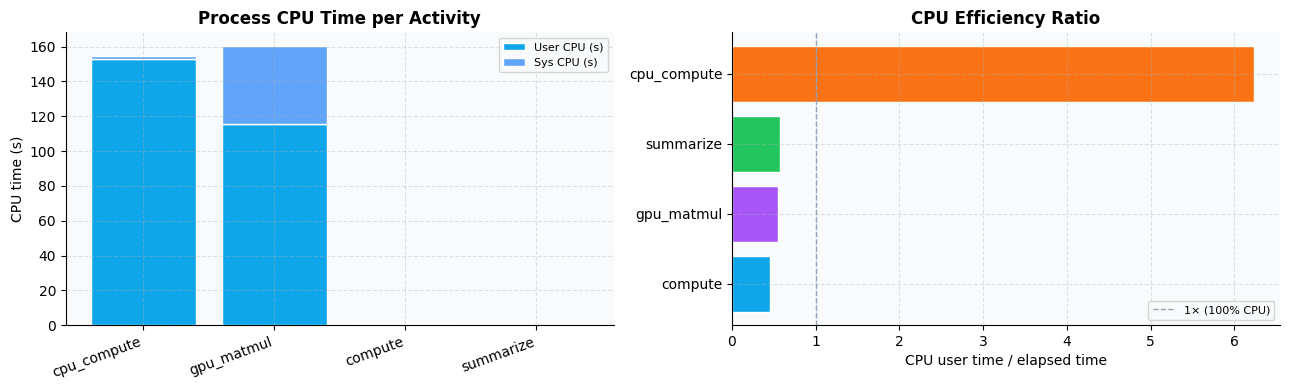

In [41]:
cpu_cols = ['cpu_user_s', 'cpu_sys_s', 'sys_cpu_pct']
cpu_df = df[['activity'] + cpu_cols].groupby('activity').sum(numeric_only=True)
print('CPU time consumed per activity (process-level):')
print(cpu_df.sort_values('cpu_user_s', ascending=False).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Stacked bar: user + sys CPU seconds
order = cpu_df.sort_values('cpu_user_s', ascending=False).index
user_vals = [cpu_df.loc[a, 'cpu_user_s'] or 0 for a in order]
sys_vals  = [cpu_df.loc[a, 'cpu_sys_s']  or 0 for a in order]
x = range(len(order))
axes[0].bar(x, user_vals, label='User CPU (s)', color='#0ea5e9', edgecolor='white')
axes[0].bar(x, sys_vals,  label='Sys CPU (s)',  color='#60a5fa', bottom=user_vals, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(order, rotation=20, ha='right')
axes[0].set_ylabel('CPU time (s)')
axes[0].set_title('Process CPU Time per Activity', fontweight='bold')
axes[0].legend(fontsize=8)

# CPU efficiency: cpu_user / elapsed
eff = df.groupby('activity').apply(
    lambda g: (g['cpu_user_s'].sum() / g['elapsed_s'].sum()) if g['elapsed_s'].sum() else 0
).sort_values(ascending=False)
eff_order = eff.index
bars = axes[1].barh(range(len(eff_order)), eff.values,
                    color=[act_color[a] for a in eff_order], edgecolor='white')
axes[1].set_yticks(range(len(eff_order)))
axes[1].set_yticklabels(eff_order)
axes[1].axvline(1.0, color='#94a3b8', linestyle='--', linewidth=1, label='1× (100% CPU)')
axes[1].set_xlabel('CPU user time / elapsed time')
axes[1].set_title('CPU Efficiency Ratio', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].invert_yaxis()

fig.tight_layout()
plt.show()

## 6 · GPU Profiling

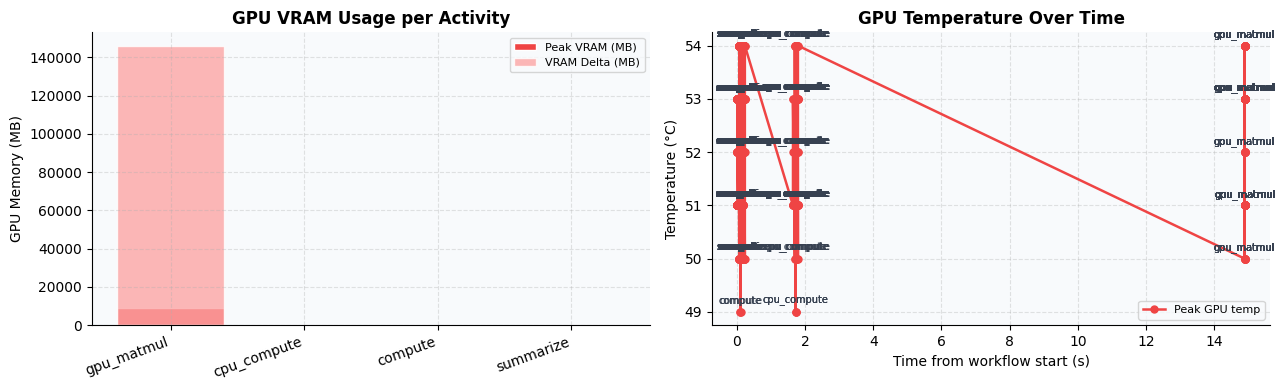

In [42]:
gpu_available = df['gpu_used_mb'].notna().any()
if not gpu_available:
    print('No GPU telemetry in this dataset.')
else:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # GPU VRAM peak per activity
    gpu_peak = df.groupby('activity')['gpu_used_mb'].max().sort_values(ascending=False).dropna()
    gpu_delta = df.groupby('activity')['gpu_delta_mb'].sum().reindex(gpu_peak.index).fillna(0)
    x = range(len(gpu_peak))

    axes[0].bar(x, gpu_peak.values, label='Peak VRAM (MB)', color='#ef4444', edgecolor='white')
    axes[0].bar(x, gpu_delta.values, label='VRAM Delta (MB)', color='#fca5a5',
                edgecolor='white', alpha=0.8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(gpu_peak.index, rotation=20, ha='right')
    axes[0].set_ylabel('GPU Memory (MB)')
    axes[0].set_title('GPU VRAM Usage per Activity', fontweight='bold')
    axes[0].legend(fontsize=8)

    # GPU temperature over time
    gpu_temp_pts = []
    for _, row in raw.iterrows():
        e = row['telemetry_at_end'] or {}
        gpu_e = _get(e, 'gpu') or {}
        for gd in gpu_e.values():
            if not isinstance(gd, dict):
                continue
            td = gd.get('temperature') or {}
            temps = [_arr(v) for v in td.values() if _arr(v) is not None]
            if temps:
                gpu_temp_pts.append((row['ended_at'] - t0, max(temps),
                                     row['activity_id']))

    if gpu_temp_pts:
        gpu_temp_pts.sort()
        tx, ty, ta = zip(*gpu_temp_pts)
        axes[1].plot(tx, ty, marker='o', linewidth=1.8, markersize=5,
                     color='#ef4444', label='Peak GPU temp')
        for xi, yi, ai in zip(tx, ty, ta):
            axes[1].annotate(ai, (xi, yi), textcoords='offset points',
                             xytext=(0, 6), ha='center', fontsize=7, color='#374151')
        axes[1].set_xlabel('Time from workflow start (s)')
        axes[1].set_ylabel('Temperature (°C)')
        axes[1].set_title('GPU Temperature Over Time', fontweight='bold')
        axes[1].legend(fontsize=8)

    fig.tight_layout()
    plt.show()

## 7 · IO Profiling (Process-level VFS IO — includes Lustre)

Process IO per activity (MB):
              io_read_mb  io_write_mb  io_total_mb
activity                                          
gpu_matmul   2103.879680     0.000000   2103.87968
cpu_compute     3.342336   512.098304    515.44064
compute         0.000000     0.000000      0.00000
summarize       0.000000     0.000000      0.00000


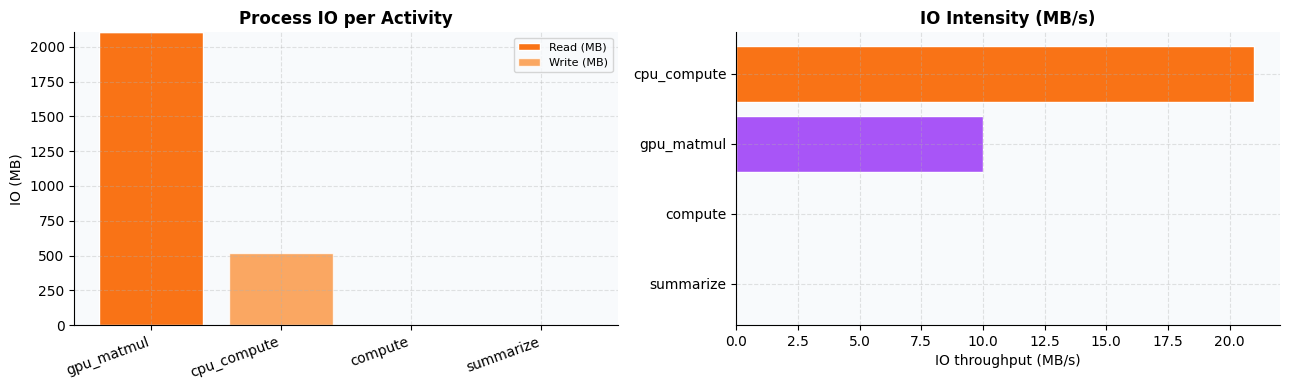

In [43]:
io_available = df['io_total_mb'].notna().any() and df['io_total_mb'].gt(0).any()
if not io_available:
    print('No process IO data in this dataset (enable process_info: true in flowcept_settings.yaml).')
else:
    io_agg = df.groupby('activity')[['io_read_mb','io_write_mb']].sum()
    io_agg['io_total_mb'] = io_agg['io_read_mb'] + io_agg['io_write_mb']
    order = io_agg.sort_values('io_total_mb', ascending=False).index
    print('Process IO per activity (MB):')
    print(io_agg.loc[order].to_string())

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    x = range(len(order))
    read_vals  = [io_agg.loc[a, 'io_read_mb']  for a in order]
    write_vals = [io_agg.loc[a, 'io_write_mb'] for a in order]
    axes[0].bar(x, read_vals,  label='Read (MB)',  color='#f97316', edgecolor='white')
    axes[0].bar(x, write_vals, label='Write (MB)', color='#fb923c',
                bottom=read_vals, edgecolor='white', alpha=0.8)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(order, rotation=20, ha='right')
    axes[0].set_ylabel('IO (MB)')
    axes[0].set_title('Process IO per Activity', fontweight='bold')
    axes[0].legend(fontsize=8)

    # IO intensity: io_total / elapsed
    io_rate = df.groupby('activity').apply(
        lambda g: (g['io_total_mb'].sum() / g['elapsed_s'].sum()) if g['elapsed_s'].sum() else 0
    ).sort_values(ascending=False)
    axes[1].barh(range(len(io_rate)), io_rate.values,
                 color=[act_color[a] for a in io_rate.index], edgecolor='white')
    axes[1].set_yticks(range(len(io_rate)))
    axes[1].set_yticklabels(io_rate.index)
    axes[1].set_xlabel('IO throughput (MB/s)')
    axes[1].set_title('IO Intensity (MB/s)', fontweight='bold')
    axes[1].invert_yaxis()

    fig.tight_layout()
    plt.show()

## 8 · Memory Profiling

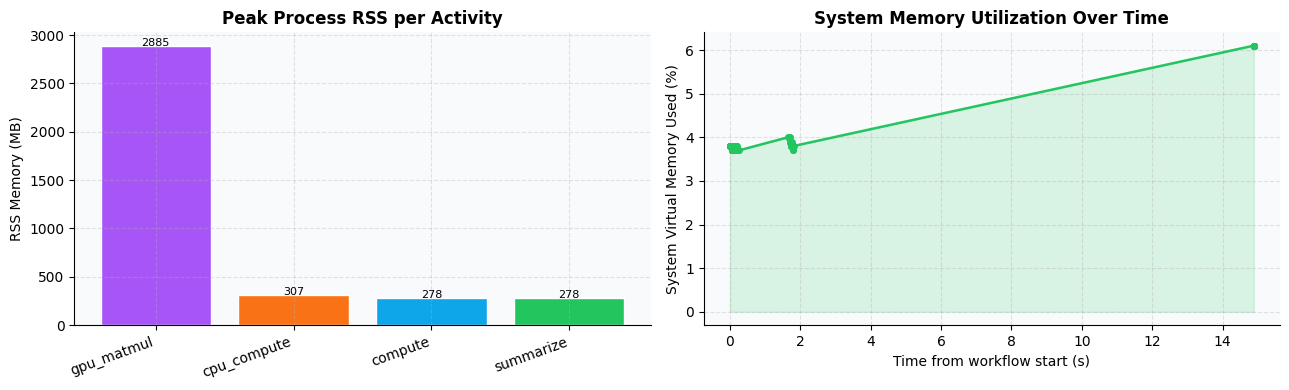

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Peak RSS per activity
rss_peak = df.groupby('activity')['mem_rss_mb'].max().sort_values(ascending=False)
x = range(len(rss_peak))
axes[0].bar(x, rss_peak.values, color=[act_color[a] for a in rss_peak.index], edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(rss_peak.index, rotation=20, ha='right')
axes[0].set_ylabel('RSS Memory (MB)')
axes[0].set_title('Peak Process RSS per Activity', fontweight='bold')
for i, v in enumerate(rss_peak.values):
    if v:
        axes[0].text(i, v + 5, f'{v:.0f}', ha='center', fontsize=8)

# Virtual memory % over time
times, virt_pct = build_series(['memory','virtual','percent'])
if times:
    axes[1].plot(times, virt_pct, color='#22c55e', marker='o', linewidth=1.8, markersize=4)
    axes[1].fill_between(times, virt_pct, alpha=0.15, color='#22c55e')
    axes[1].set_xlabel('Time from workflow start (s)')
    axes[1].set_ylabel('System Virtual Memory Used (%)')
    axes[1].set_title('System Memory Utilization Over Time', fontweight='bold')

fig.tight_layout()
plt.show()

## 9 · Performance Characterization Summary

Performance characterization per activity:
             n_tasks  median_s  cpu_score  io_score  gpu_score  mem_score  dominant
activity                                                                           
gpu_matmul        16     13.14       0.76      1.00       1.00       1.00        IO
cpu_compute       16      1.53       1.00      0.24       0.00       0.01       CPU
compute           80      0.01       0.00      0.00       0.00       0.00  Balanced
summarize         16      0.01       0.00      0.00       0.00       0.00  Balanced


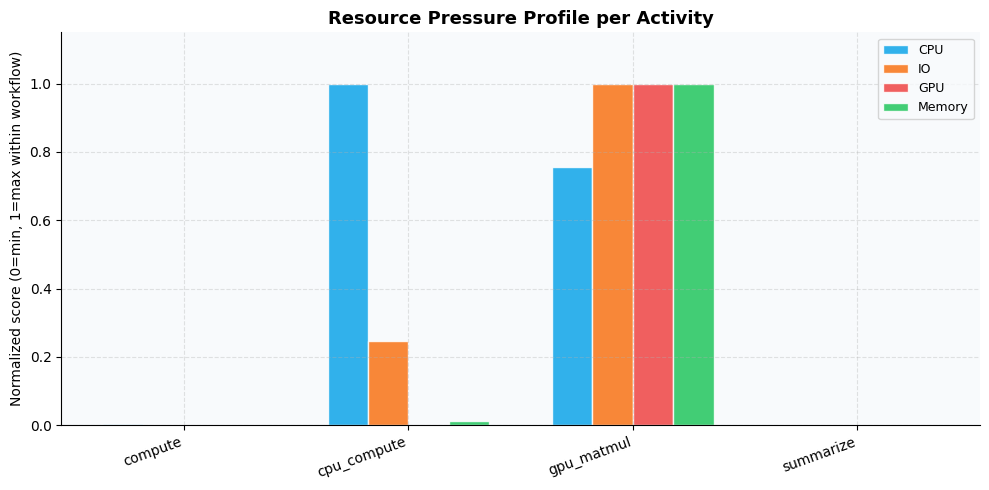


Dominant resource type:
  compute              → Balanced
  cpu_compute          → CPU
  gpu_matmul           → IO
  summarize            → Balanced


In [45]:
# Score each activity on four axes (normalized 0-1 within the workflow)
def norm_series(s):
    lo, hi = s.min(), s.max()
    return (s - lo) / (hi - lo) if hi > lo else s * 0

agg = df.groupby('activity').agg(
    elapsed_s   = ('elapsed_s',    'median'),
    cpu_user_s  = ('cpu_user_s',   'sum'),
    io_total_mb = ('io_total_mb',  'sum'),
    gpu_used_mb = ('gpu_used_mb',  'max'),
    mem_rss_mb  = ('mem_rss_mb',   'max'),
    n_tasks     = ('activity',     'count'),
).fillna(0)

agg['cpu_score'] = norm_series(agg['cpu_user_s'])
agg['io_score']  = norm_series(agg['io_total_mb'])
agg['gpu_score'] = norm_series(agg['gpu_used_mb'])
agg['mem_score'] = norm_series(agg['mem_rss_mb'])

def classify(row):
    scores = {'CPU': row['cpu_score'], 'IO': row['io_score'],
              'GPU': row['gpu_score'], 'Mem': row['mem_score']}
    dom = max(scores, key=scores.get)
    return dom if scores[dom] > 0.5 else 'Balanced'

agg['dominant'] = agg.apply(classify, axis=1)

print('Performance characterization per activity:')
print(agg[['n_tasks','elapsed_s','cpu_score','io_score','gpu_score','mem_score','dominant']]
      .sort_values('elapsed_s', ascending=False)
      .rename(columns={'elapsed_s':'median_s'})
      .to_string(float_format='{:.2f}'.format))

# Grouped bar: scores side-by-side
score_cols = ['cpu_score','io_score','gpu_score','mem_score']
score_labels = ['CPU','IO','GPU','Memory']
score_colors = ['#0ea5e9','#f97316','#ef4444','#22c55e']

acts = agg.index.tolist()
n_acts = len(acts)
n_scores = len(score_cols)
width = 0.18
x = np.arange(n_acts)

fig, ax = plt.subplots(figsize=(max(10, n_acts * 1.5), 5))
for i, (col, label, color) in enumerate(zip(score_cols, score_labels, score_colors)):
    offset = (i - n_scores/2 + 0.5) * width
    vals = [agg.loc[a, col] for a in acts]
    bars = ax.bar(x + offset, vals, width, label=label, color=color, edgecolor='white', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(acts, rotation=20, ha='right')
ax.set_ylabel('Normalized score (0=min, 1=max within workflow)')
ax.set_title('Resource Pressure Profile per Activity', fontweight='bold', fontsize=13)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.15)
fig.tight_layout()
plt.show()

# Dominant resource type summary
print('\nDominant resource type:')
for a in acts:
    d = agg.loc[a, 'dominant']
    print(f'  {a:<20} → {d}')

## 10 · Compute Node Breakdown

Per-node, per-activity summary:
                           n_tasks  total_s  median_s  cpu_user_s  io_write_mb  gpu_used_mb
node          activity                                                                     
frontier01258 compute           40     0.62      0.02        0.27         0.00        11.36
              cpu_compute        8    12.37      1.55       76.20       256.05        11.91
              gpu_matmul         8   105.18     13.14       58.68         0.00      9124.04
              summarize          8     0.10      0.01        0.07         0.00        11.36
frontier01259 compute           40     0.58      0.01        0.28         0.00        11.36
              cpu_compute        8    12.17      1.52       76.86       256.05        11.84
              gpu_matmul         8   104.97     13.13       57.14         0.00      9124.04
              summarize          8     0.11      0.01        0.05         0.00        11.36


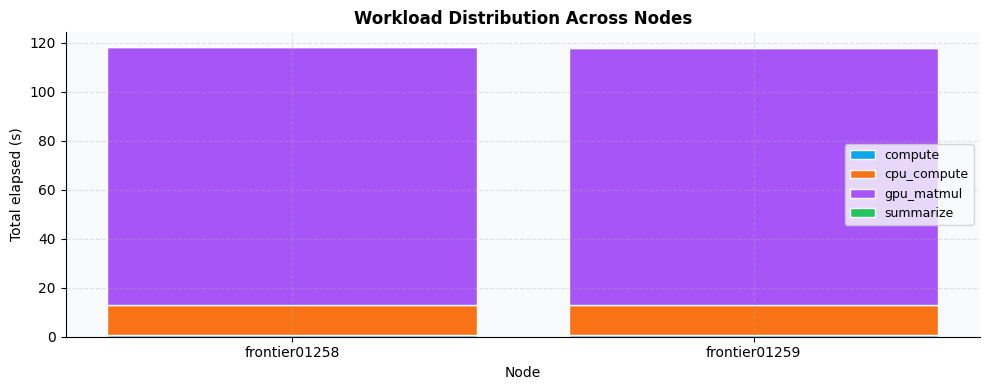

In [46]:
node_df = df.copy()
node_df['node'] = node_df['hostname'].str.split('.').str[0]

node_summary = node_df.groupby(['node','activity']).agg(
    n_tasks     = ('elapsed_s', 'count'),
    total_s     = ('elapsed_s', 'sum'),
    median_s    = ('elapsed_s', 'median'),
    cpu_user_s  = ('cpu_user_s','sum'),
    io_write_mb = ('io_write_mb','sum'),
    gpu_used_mb = ('gpu_used_mb','max'),
).fillna(0)

print('Per-node, per-activity summary:')
print(node_summary.to_string(float_format='{:.2f}'.format))

# If multi-node: show workload balance across nodes
if node_df['node'].nunique() > 1:
    fig, ax = plt.subplots(figsize=(10, 4))
    pivot = node_df.groupby(['node','activity'])['elapsed_s'].sum().unstack(fill_value=0)
    bottom = np.zeros(len(pivot))
    for j, act in enumerate(pivot.columns):
        vals = pivot[act].values
        ax.bar(pivot.index, vals, bottom=bottom,
               label=act, color=act_color[act], edgecolor='white')
        bottom += vals
    ax.set_xlabel('Node')
    ax.set_ylabel('Total elapsed (s)')
    ax.set_title('Workload Distribution Across Nodes', fontweight='bold')
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()
else:
    node = node_df['node'].iloc[0]
    print(f'\nAll tasks ran on single node: {node}')